In [4]:
import numpy as np 

In [9]:
x = np.array([1,2,3,4])
x
y = np.array([[1],[2],[3],[4]])

y

array([[1],
       [2],
       [3],
       [4]])

Bhai, ye NumPy ka ek bohot hi powerful (aur kabhi-kabhi dimaag ghumane wala) feature hai jise **Broadcasting** kehte hain.

Chalo isko aasan bhasha mein samajhte hain ki parde ke peeche kya chal raha hai.

### Khiladiyon Ka Size (Shapes)

Sabse pehle dono arrays ka shape dekho:

* `x` ka shape hai `(4,)` — Yeh ek **1D array** hai (row vector ki tarah).
* `y` ka shape hai `(4, 1)` — Yeh ek **2D array** hai (column vector).

Jab tum `x + y` karte ho, toh NumPy dono ke shapes ko match karne ki koshish karta hai. Kyunki dono ka shape same nahi hai, NumPy **Broadcasting Rules** apply karta hai.

---

### Parde Ke Peeche Kya Hua? (The Visual)

NumPy dono arrays ko tab tak "stretches" (khinchta) hai jab tak unka shape ek dusre se match na kar jaye:

1. **`x` ko stretch kiya gaya:** `x` jo ki `[1, 2, 3, 4]` tha, usko row-wise stretch karke 2D bana diya gaya taaki usme 4 rows ho sakein.
2. **`y` ko stretch kiya gaya:** `y` jo ki ek column tha, usko column-wise stretch kiya gaya taaki usme 4 columns ho sakein.

Ab dono arrays dikhne mein aise ho jaate hain:

```text
    Array X (Stretched)            Array Y (Stretched)
    [[1, 2, 3, 4],                 [[1, 1, 1, 1],
     [1, 2, 3, 4],       +          [2, 2, 2, 2],
     [1, 2, 3, 4],                  [3, 3, 3, 3],
     [1, 2, 3, 4]]                  [4, 4, 4, 4]]

```

---

### Final Output Kaise Aya?

Ab NumPy in dono stretched arrays ka **element-by-element addition** kar deta hai:

* **Row 1:** `[1+1, 2+1, 3+1, 4+1]` $\rightarrow$ `[2, 3, 4, 5]`
* **Row 2:** `[1+2, 2+2, 3+2, 4+2]` $\rightarrow$ `[3, 4, 5, 6]`
* **Row 3:** `[1+3, 2+3, 3+3, 4+3]` $\rightarrow$ `[4, 5, 6, 7]`
* **Row 4:** `[1+4, 2+4, 3+4, 4+4]` $\rightarrow$ `[5, 6, 7, 8]`

Isiliye tumhara final output ek **4x4 ka 2D array** nikal ke aata hai:

```python
array([[2, 3, 4, 5],
       [3, 4, 5, 6],
       [4, 5, 6, 7],
       [5, 6, 7, 8]])

```

> **Gyaan ki baat:** Agar tum chahte ho ki normal element-by-element plus ho (jaise `[1+1, 2+2...]`), toh dono ka shape exact same hona chahiye. Us case mein `y` ko bhi simple 1D array `np.array([1, 2, 3, 4])` hona padega.

NumPy mein broadcasting tab fail ho jaati hai jab dono arrays ke dimensions aapas mein **compatible** nahi hote.

Broadcasting ka ek seedha sa rule hai: Jab aap dono arrays ke shapes ko **right to left (piche se aage)** compare karte ho, toh har ek dimension ke liye yeh shart poori honi chahiye:

1. Ya toh dono dimensions **barabar (equal)** hon.
2. Ya fir unme se koi ek **1** ho.

Agar in dono mein se koi bhi shart poori nahi hoti, toh NumPy haath khade kar dega aur aapko `ValueError: operands could not be broadcast together` de dega.

Chalo kuch badiya examples se dekhte hain ki kab yeh broadcast nahi ho payenge:

### 1. Jab dono arrays 1D hon par unka size alag ho

Maan lo aapke paas do simple arrays hain:

* `a` ka shape: `(4,)` — `[1, 2, 3, 4]`
* `b` ka shape: `(3,)` — `[1, 2, 3]`

Jab aap `a + b` karoge, toh NumPy piche se check karega: `4` aur `3`. Na toh ye barabar hain, aur na hi dono mein se koi `1` hai.

```python
import numpy as np
a = np.array([1, 2, 3, 4])
b = np.array([1, 2, 3])
# a + b  --> ValueError!

```

---

### 2. Matrix ke sath Rows ya Columns match na ho rahe hon (2D vs 1D/2D)

Maan lo aapke paas ek $3 \times 3$ ka matrix hai, aur aap usme ek vector add karna chahte ho.

* **Matrix `M` ka shape:** `(3, 3)`
* **Vector `v` ka shape:** `(2,)` — `[10, 20]`

Chalo piche se shape compare karte hain:

* Sabse right ka dimension: Matrix ka `3` hai aur Vector ka `2` hai.
* Na dono barabar hain, na koi `1` hai. Game over!

```python
M = np.ones((3, 3))  # 3x3 matrix
v = np.array([10, 20]) # 1D array of size 2
# M + v  --> ValueError!

```

Agar `v` ka shape `(3,)` hota, toh yeh har row mein perfectly broadcast ho jata. Lekin `2` hone ki wajah se NumPy samajh hi nahi paata ki isko stretch kaise kare.

---

### 3. Cheat Sheet: Kaise check karein ki broadcast hoga ya nahi?

Aap khud dimaag mein ya copy par dono ke shapes ko right-align karke likh lo:

**Case A (Will Fail ❌):**

```text
Array 1 Shape:    3  x  4
Array 2 Shape:          3
                  -------
Mismatch! Last dim 4 aur 3 match nahi huye.

```

**Case B (Will Fail ❌):**

```text
Array 1 Shape:    4  x  3
Array 2 Shape:    4  x  2
                  -------
Mismatch! Last dim 3 aur 2 match nahi huye (halaanki aage ka 4 same hai, par piche se fail ho gaya).

```

**Case C (Will Pass  (Pichle question wala case)):**

```text
Array 1 Shape:    4  x  1  (y)
Array 2 Shape:          4  (x)
                  -------
Pass! 1 aur 4 compatible hain (1 stretch ho jayega), aur aage 4 ke upar kuch nahi hai toh wo bhi compatible hai.

```

Ek line mein bole toh: **Agar right-to-left check karte waqt numbers alag-alag aa jayein aur unme se koi bhi `1` na ho, toh broadcasting fail ho jayegi.**

In [10]:
x.shape
y.shape

(4, 1)

In [11]:
x+y

array([[2, 3, 4, 5],
       [3, 4, 5, 6],
       [4, 5, 6, 7],
       [5, 6, 7, 8]])

In [12]:
x = np.arange(4).reshape(1,4)
y = np.arange(16).reshape(4,4)

Bhai, is baar tumne ek **1D array** aur ek **2D array** ki direct bhidant karwayi hai, aur dono ke shapes ekdam perfect setting mein hain.

Chalo isko tod ke dekhte hain ki `x` kya hai, `y` kya hai, aur agar tum inka kuch operation (jaise `x + y`) karoge toh kya hoga.

### 1. `x = np.arange(4).reshape(1,4)`

* `np.arange(4)` ne pehle generate kiya: `[0, 1, 2, 3]`
* `.reshape(1,4)` ne ise ek **2D array (Row Matrix)** bana diya jisme **1 row aur 4 columns** hain.
* **`x` dikhne mein aisa hai:**
```python
[[0, 1, 2, 3]]

```


*(Shape: `(1, 4)`)*

---

### 2. `y = np.arange(16).reshape(4,4)`

* `np.arange(16)` ne 0 se lekar 15 tak ke numbers generate kiye.
* `.reshape(4,4)` ne use ek **4 rows aur 4 columns** ke grid (matrix) mein convert kar diya.
* **`y` dikhne mein aisa hai:**
```python
[[ 0,  1,  2,  3],
 [ 4,  5,  6,  7],
 [ 8,  9, 10, 11],
 [12, 13, 14, 15]]

```


*(Shape: `(4, 4)`)*

---

### Agar tum `x + y` karoge, toh kya yeh broadcast hoga?

**Haan, bilkul hoga!** Chalo wahi pichle waala rule lagate hain (Right to Left check):

```text
y ka shape:   4  x  4
x ka shape:   1  x  4
             ---------
           (Pass)  (Pass)

```

* **Last dimension (4 aur 4):** Dono barabar hain $\rightarrow$ **Pass!**
* **Aage ka dimension (4 aur 1):** Ek jagah `1` aa gaya, iska matlab yeh stretch ho sakta hai $\rightarrow$ **Pass!**

#### Parde ke peeche kya stretching hogi?

NumPy `x` ko vertical direction mein (downwards) stretch karega taaki uski 1 row ki jagah 4 rows ho jayein:

```text
   Original X                     Stretched X (4x4)
  [[0, 1, 2, 3]]   ----->   [[0, 1, 2, 3],
                             [0, 1, 2, 3],
                             [0, 1, 2, 3],
                             [0, 1, 2, 3]]

```

Ab yeh stretched `x`, tumhare matrix `y` ke har ek row mein element-by-element add ho jayega:

* **Row 0:** `[0,1,2,3]` + `[0,1,2,3]` = `[0, 2, 4, 6]`
* **Row 1:** `[4,5,6,7]` + `[0,1,2,3]` = `[4, 6, 8, 10]`
* ...aur aise hi baaki rows bhi chalengi.

Moti baat yeh hai ki `reshape(1,4)` karne se yeh ek aisi strip (patti) ban gaya jisko niche ki taraf khinch ke poore $4 \times 4$ matrix ke upar thopa ja sakta hai!

In [13]:
x+y

array([[ 0,  2,  4,  6],
       [ 4,  6,  8, 10],
       [ 8, 10, 12, 14],
       [12, 14, 16, 18]])

In [14]:

x1  = np.tile(x,(3,2))
x1

array([[0, 1, 2, 3, 0, 1, 2, 3],
       [0, 1, 2, 3, 0, 1, 2, 3],
       [0, 1, 2, 3, 0, 1, 2, 3]])

# For Broadcasting
# two dimesion should be same or either of them is 1

In [15]:
# Broadcasting in NumPy:
# Agar arrays ke shapes me kisi dimension ka size 1 ho ya dono ka size same ho,
# to NumPy unhe automatically compatible shape me badal deta hai aur operation perform karta hai.

print("x.shape =", x.shape)
print("y.shape =", y.shape)

# x ka shape (1, 4) hai aur y ka shape (4, 4).
# Pehli dimension x me 1 hai, isliye x ko 4 rows tak repeat karke y ke saath add kiya ja sakta hai.
print("x + y =")
print(x + y)

x.shape = (1, 4)
y.shape = (4, 4)
x + y =
[[ 0  2  4  6]
 [ 4  6  8 10]
 [ 8 10 12 14]
 [12 14 16 18]]


# Splitting

Arey haan, sorry bhai! Main thoda aage nikal gaya tha. Chalo pehle bilkul basic se samajhte hain ki yeh **`split`** bala kya hai.

**`split` ka seedha matlab hai: Tukde-tukde karna (To break into pieces).**

Jaise hum real life mein ek badi chocolate bar ko tod kar uske chhote-chhote hisse kar dete hain na? Bilkul waise hi, NumPy mein `np.split()` ka kaam hota hai **ek bade array ya matrix ko tod kar uske chhote-chhote arrays bana dena.**

---

### Ek simple example se samjho (1D Array)

Maan lo tumhare paas ek array hai jisme 6 elements hain:

```python
import numpy as np

# Ek badi chocolate bar (size 6)
bada_array = np.array([10, 20, 30, 40, 50, 60])

```

Ab tum chahte ho ki iske **3 barabar tukde** ho jayein. Toh tum bologe: *"NumPy, is `bada_array` ko `3` hisson mein split kar do."*

```python
tukde = np.split(bada_array, 3)

```

Ab NumPy isko barabar baant kar tumhe **3 chhote arrays ki ek list** de dega:

* Tukda 1: `[10, 20]`
* Tukda 2: `[30, 40]`
* Tukda 3: `[50, 60]`

---

### Split ka sabse zaroori niyam (Rule)

NumPy split karte waqt ekdum pakka hisaab-kitaab chahta hai. **Tum jitne tukde bol rahe ho, wo barabar hone chahiye.**

* Agar tumhare paas **6** elements hain, toh tum use **2** tukdon mein tod sakte ho (3-3 milenge) ya **3** tukdon mein (2-2 milenge).
* Lekin agar tumne bol diya: *"6 elements hain, isko **4** tukdon mein tod do."* — toh NumPy gussa ho jayega aur **Error** de dega (`ValueError: array split does not result in an equal division`). Kyunki 6 ko 4 se barabar nahi baanta ja sakta point ke bina!

### Matrix (2D) mein kya hota hai?

Jab baat matrix ($4 \times 4$) ki aati hai, toh todne ke do tareeqe ho jaate hain jo humne upar dekhe thhe:

1. **Roti ki tarah bich se kaatna (Rows alag karna):** Jise `axis=0` bolte hain.
2. **Kheer Mohan ya Cake ki tarah vertical cut maarna (Columns alag karna):** Jise `axis=1` bolte hain.

Ab samajh aaya ki `split` kya hai? Bas ek bade array ko chhote arrays mein todne ki machine!

In [17]:
x = np.arange(9)
# Split the array into three part
np.split(x,3)
np.split(x,[1,2]) # multiple spliting

[array([0]), array([1]), array([2, 3, 4, 5, 6, 7, 8])]

In [18]:
x = np.arange(16).reshape(4,4)

In [19]:
x

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15]])

Bhai, `vsplit` ka matlab hota hai **Vertical Split** (khade-khade kaatna).

Lekin yahan NumPy mein ek chota sa twist hai jo naye-naye developers ko bohot confuse karta hai. Naam hai "Vertical", par yeh matrix ko **horizontally** (bich se aade mein) kaat-ta hai taaki aapko **Rows** alag-alag mil sakein.

Isko yaad rakhne ka sabse aasan tareeqa yeh hai: **"Vertical axis par chalte hue cuts maarna."** Jab aap upar se neeche (vertically) chaloge aur talwar chalaoge, toh matrix aade mein kategi!

---

### Ek simple example se dekho

Maan lo aapke paas ek $4 \times 4$ ka matrix `x` hai (jo tumne pichle question mein banaya tha):

```python
import numpy as np

x = np.array([[ 0,  1,  2,  3],
              [ 4,  5,  6,  7],
              [ 8,  9, 10, 11],
              [12, 13, 14, 15]])

```

Ab agar aap karte ho `np.vsplit(x, 2)`, toh aap NumPy se keh rahe ho: *"Bhai, isko vertical axis par chalte hue 2 barabar hisson mein kaat do."*

```python
tukde = np.vsplit(x, 2)

```

### Output kya milega?

NumPy upar ki 2 rows alag kar dega aur neeche ki 2 rows alag kar dega. Aapko 2 arrays ki ek list milegi:

* **Pehla Tukda (`tukde[0]`):**
```python
[[0, 1, 2, 3],
 [4, 5, 6, 7]]

```


* **Dusra Tukda (`tukde[1]`):**
```python
[[ 8,  9, 10, 11],
 [12, 13, 14, 15]]

```



---

### `vsplit` aur `split(axis=0)` mein kya rishta hai?

Dono ekdam **judwa bhai** hain.
`np.vsplit(x, 2)` likhna aur `np.split(x, 2, axis=0)` likhna bilkul ek hi baat hai. `vsplit` bas ek shortcut hai taaki aapko baar-baar `axis=0` na likhna pade.

### Yeh kab fail hoga?

Jaise `split` ka rule hai, `vsplit` mein bhi **rows barabar baantni chahiye**.
Agar aapke matrix mein 4 rows hain, toh aap use 2 ya 4 hisson mein toh `vsplit` kar sakte ho. Lekin agar aapne `np.vsplit(x, 3)` likh diya, toh yeh error de dega kyunki 4 rows ko 3 barabar hisson mein nahi kaata ja sakta!

Arey dhutt teri ki! 😂 Main Data Structures wale Stack par nikal gaya, jabki tum NumPy padh rahe ho! My bad, bhai.

NumPy mein **`np.stack()`** ka matlab bilkul alag hai. Yahan iska kaam hai **do ya do se zyada arrays ko aapas mein jodna (join karna), ek naye axis (dimension) ke sath.**

Isko simple bhasha mein samjho: Jaise shadi ke card ke lifafe hote hain. Ek single lifafa 1D hai, par jab tum ek ke upar ek 4-5 lifafe rakh dete ho, toh woh ek poori gaddi (2D) ban jaati hai. NumPy mein arrays ko aise hi ek ke upar ek pile (stack) karne ko `np.stack()` bolte hain.

---

### Ek Simple Example Se Samjho

Maan lo tumhare paas do simple 1D arrays hain:

```python
import numpy as np

a = np.array([1, 2, 3])  # Shape: (3,)
b = np.array([4, 5, 6])  # Shape: (3,)

```

Ab agar tum in dono ko stack karte ho:

```python
c = np.stack((a, b), axis=0)

```

**Output kya milega?**
NumPy in dono 1D arrays ko uthayega aur ek ke upar ek rakh kar ek **2D Matrix** bana dega:

```python
array([[1, 2, 3],
       [4, 5, 6]])

```

*(Ab iska shape ho gaya `(2, 3)` — yaani 2 rows aur 3 columns).*

---

### Iske Do Alag Variants (Jo bohot use hote hain)

NumPy ne humari aasan ke liye do shortcuts diye hain:

#### 1. `np.vstack()` (Vertical Stack)

Yeh arrays ko **vertically (row-wise)** ek ke upar ek jodta hai.

```python
np.vstack((a, b))
# Output same upar wale jaisa milega:
# [[1, 2, 3],
#  [4, 5, 6]]

```

#### 2. `np.hstack()` (Horizontal Stack)

Yeh arrays ko **horizontally (column-wise)** side-by-side jodta hai, yaani aage tail ki tarah laga deta hai.

```python
np.hstack((a, b))
# Output ek bada 1D array ban jayega:
# array([1, 2, 3, 4, 5, 6])

```

### `np.stack()` aur `np.concatenate()` mein kya farak hai?

* **`concatenate`** purane axis par hi arrays ko aage jod deta hai (dimension nahi badhta).
* **`stack`** hamesha ek **naya axis** create karta hai (jaise do 1D array milkar 2D ban jayenge, do 2D arrays milkar 3D ban jayenge).

Ab clear hua NumPy ka stack? 😅

In [ ]:
import numpy as np
x = np.arange(16).reshape(4,4)
x
np.split(x, 4, axis=1)
np.vsplit(x,2) # vertical axis me chalte hue to part me split kar do 

[array([[0, 1, 2, 3],
        [4, 5, 6, 7]]),
 array([[ 8,  9, 10, 11],
        [12, 13, 14, 15]])]

In [ ]:
# stack,vstack,hstack,vsplit,split,copy
x = np.arange(5)
y = np.arange(5)
# ek ke Upar ek 
np.stack((x,y))
np.vstack((x,y))
# ek ke aage dusra 
np.hstack((x,y))

array([0, 1, 2, 3, 4, 0, 1, 2, 3, 4])

Bhai, NumPy mein **`copy`** ka concept bohot zaroori hai, kyunki agar isko nahi samjha toh tumhare data mein aisi galtiyan hongi jo pakad mein bhi nahi aayengi.

Simple bhasha mein, NumPy mein jab tum ek array se dusra array banate ho, toh do tareeqe hote hain: ek hota hai **View (sirf dekhne ke liye)** aur ek hota hai **Copy (ekdam naya aur alag)**.

Chalo dono ka farak ekdam mast real-life example se samajhte hain.

---

### 1. View (Abe yeh toh nakli hai! ❌)

Jab tum bina `.copy()` lagaye direct `y = x` likh dete ho ya array ka koi slice nikaalte ho, toh NumPy naya data nahi banata. Wo purane data ka hi ek **View (shisha/mirror)** dikha deta hai.

Maan lo tumhare paas ek array hai:

```python
import numpy as np
x = np.array([1, 2, 3, 4])
y = x  # Yeh bana ek View!

```

Ab agar tum `y` mein koi badlav karoge, toh **`x` bhi badal jayega!** Kyunki `x` aur `y` dono parde ke peeche ek hi memory location ko point kar rahe hain.

```python
y[0] = 99
print(x) # Output: [99, 2, 3, 4] <-- Dekha? x bhi badal gaya!

```

---

### 2. Copy (Yeh hai asli naya maal!  )

Jab tum chahte ho ki purane array se ekdam azaad, ek naya array bane jiska purane wale se koi lena-dena na ho, tab tum use karte ho **`.copy()`**.

```python
x = np.array([1, 2, 3, 4])
y = x.copy()  # Yeh bani ekdam kora-kagaz asli Copy!

```

Ab `y` ka apna khud ka alag ghar (memory space) hai. Agar tum `y` mein tod-fod machaoge, toh `x` ko ghanta farak nahi padega:

```python
y[0] = 99
print(y) # Output: [99, 2, 3, 4]
print(x) # Output: [1, 2, 3, 4] <-- x ekdam safe hai!

```

---

### Slicing mein sabse bada dhoka! ⚠️

Python ki normal lists mein jab tum slicing karte ho (`list[0:2]`), toh woh hamesha ek **copy** banata hai. **Lekin NumPy mein aisa nahi hota!**

NumPy mein memory bachane ke liye, **slicing hamesha ek view return karti hai.**

```python
x = np.array([10, 20, 30, 40])
tukda = x[0:2] # Yeh copy nahi hai, yeh VIEW hai!

tukda[0] = 999
print(x) # Output: [999, 20, 30, 40] <-- Original array badal gaya!

```

**Sahi tareeqa:** Agar tum slice kiye huye tukde ko alag rakhna chahte ho, toh hamesha peeche `.copy()` lagao:

```python
tukda = x[0:2].copy() # Ab yeh ekdam safe hai

```

Moti baat yeh hai: Agar original array ko safe rakhna hai aur naye array par operations karne hain, toh bina kanjoosi ke `.copy()` ka istemaal karo!

Bhai, yeh ek bohot hi shaandar trick question hai! Abhi jo humne **Copy vs View** padha na, yeh poora khel usi ka hai, par isme ek bohot bada twist hai jise NumPy mein **Fancy Indexing (ya Boolean Indexing)** kehte hain.

Pehle code ko step-by-step todte hain ki tumhara output `[10, 1]` kaise aaya:

---

### Step 1: `a = np.array([0, 1, 2, 3, 4, 5])`

Yeh toh seedha hai, ek basic 1D array ban gaya.

### Step 2: `b = a[a % 1 == 0]`

Yahan par asal khel shuru hota hai.

1. `a % 1 == 0` kya karega? Kisi bhi integer ko `1` se divide karoge toh remainder `0` hi aayega. Toh yeh condition sabhi elements ke liye `True` ho jayegi.
2. NumPy ko parde ke peeche ek boolean array milega: `[True, True, True, True, True, True]`.
3. Jab tum `a[...]` ke andar koi condition ya indices ki list bhejte ho, toh use **Fancy/Boolean Indexing** kehte hain.

> **Sabse Bada Rule:** NumPy mein normal slicing (`a[0:2]`) hamesha ek **View** return karti hai, lekin **Fancy Indexing hamesha ek COPY return karti hai!**

Iska matlab, `b` ab `a` ka view nahi hai, balki memory mein ek ekdam **naya aur azaad array** ban chuka hai jisme saare elements copy ho gaye hain: `b = [0, 1, 2, 3, 4, 5]`.

---

### Step 3: `b[0] = 10`

Tumne `b` ke pehle element ko badal kar `10` kar diya.
Kyunki `b` ek alag **copy** thi, is badlav se tumhare original array **`a` par koi asar nahi padega!** `a` abhi bhi waisa ka waisa hi hai: `[0, 1, 2, 3, 4, 5]`.

---

### Step 4: `a[:2]`

Ab tumne `a` ke pehle do elements maange (index 0 aur index 1).

* `a` ka index 0 par kya hai? `0`
* `a` ka index 1 par kya hai? `1`

Toh output aana chahiye tha: `array([0, 1])`

---

### 🚨 Wait... Toh fir image mein output `array([10, 1])` kaise dikha raha hai?!

Bhai, dhyan se code ko dekho, wahan ek choti si printing mistake (typo) hai jo aksar log dhyan nahi dete!

Wahan likha hai: `b = a[a % 1 == 0]`
Lekin jisne bhi ye quiz banaya hai, wo asal mein **`a % 2 == 0`** (Even numbers) likhna chahta tha, par galti se `% 1` likh gaya.

Agar wahan **`a % 2 == 0`** hota, toh:

1. `b` ke andar sirf even numbers aate: `[0, 2, 4]`
2. Lekin yeh fir bhi ek **Copy** hi hoti! `b[0] = 10` karne se `a` tab bhi nahi badalta.

**Toh fir output mein 10 aaya kaise?**
Iska ek hi matlab hai: Yeh code jis notebook mein chal raha hai, wahan is cell ko run karne se pehle upar kisi cell mein **`b` ko `a` ka view banaya gaya hoga** (jaise `b = a` ya `b = a[:]`), aur `b[0] = 10` chalaya gaya hoga, jisse `a[0]` ki value `10` ho gayi. Uske baad bina kernel restart kiye yeh niche wala cell chala diya gaya!

Agar tum bilkul fresh kernel par ek naye cell mein sirf itna code likhoge jo image mein hai, toh tumhara output `[0, 1]` hi aayega, `[10, 1]` nahi! NumPy ke rules ke mutabik boolean indexing hamesha copy hi banati hai.

In [32]:
## Images with Numpy

import numpy as np

# 3 pages, 3 rows, 3 columns (Total 27 elements)
x = np.arange(27).reshape(3, 3, 3)

# [start:end,start:end,start:]

Bhai, 3D array ki slicing dekh kar achhe-achhon ke tote ud jaate hain, par sach bataun toh yeh utna mushkil hai nahi. Bas thoda 3D mein imagine karna padega.

Chalo isko ekdam deshi example se samajhte hain. Imagine karo ek **Notebook (Copy)** jisme bohot saare **Pages (Panna)** hain, aur har page par ek **Table (2D Matrix)** bana hua hai.

Ek 3D array ke paas 3 cheezein (axes) hoti hain: `[page, row, column]`

---

### Pehle ek 3D Array bana lete hain

Maan lo hamare paas ek 3D array hai jisme **3 pages** hain, aur har page par **3 rows aur 3 columns** ka matrix hai:

```python
import numpy as np

# 3 pages, 3 rows, 3 columns (Total 27 elements)
x = np.arange(27).reshape(3, 3, 3)

```

Yeh dikhne mein aisa hoga:

```text
PAGE 0 (Index 0):           PAGE 1 (Index 1):           PAGE 2 (Index 2):
[[ 0,  1,  2],              [[ 9, 10, 11],              [[18, 19, 20],
 [ 3,  4,  5],               [12, 13, 14],               [21, 22, 23],
 [ 6,  7,  8]]               [15, 16, 17]]               [24, 25, 26]]

```

---

### Slicing Ka Formula

3D array mein slice karne ke liye tum teen `:` (colons) ka use karte ho:


$$\text{x[page\_start:page\_end,  row\_start:row\_end,  col\_start:col\_end]}$$

Chalo alag-alag cases dekh ke dimaag ki dahi khatam karte hain:

### Case 1: Kisi Ek Single Page Ko Nikalna

Agar mujhe sirf **Page 1** ka poora data chahiye, toh baki rows aur columns ke liye sirf `:` chor denge:

```python
print(x[1, :, :]) 
# Ya fir shortcut: x[1]

```

**Output:**

```python
[[ 9, 10, 11],
 [12, 13, 14],
 [15, 16, 17]]

```

---

### Case 2: Saare Pages Se Pehli-Pehli Row Nikalna

Ab dhyan se socho, mujhe **Page 0, Page 1, Page 2 tino chahiye** (yaani pages par `:`), par har page ki sirf **Pehli Row (index 0)** chahiye, aur saare columns chahiye (`:`).

```python
print(x[:, 0, :])

```

**Output:**

```python
[[ 0,  1,  2],   # Page 0 ki 1st row
 [ 9, 10, 11],   # Page 1 ki 1st row
 [18, 19, 20]]   # Page 2 ki 1st row

```

---

### Case 3: Sabse Khatarnak (Asli Slicing 🌶️)

Maan lo mujhe **Page 0 aur Page 1** chahiye. Un dono pages ki sirf **niche ki 2 rows** chahiye, aur un rows ke sirf **aakhiri ke 2 columns** chahiye.

Chalo formula lagate hain:

* **Pages:** 0 aur 1 chahiye $\rightarrow$ `0:2`
* **Rows:** Niche ki do (index 1 aur 2) chahiye $\rightarrow$ `1:3` (ya sirf `1:`)
* **Columns:** Aakhiri ke do (index 1 aur 2) chahiye $\rightarrow$ `1:3` (ya sirf `1:`)

```python
print(x[0:2, 1:, 1:])

```

**Output dhyan se dekho:**

```python
array([[[ 4,  5],     # Page 0 se aya
        [ 7,  8]],

       [[13, 14],     # Page 1 se aya
        [16, 17]]])

```

### 💡 Yaad rakhne ki Trick:

Jab bhi 3D array aaye, dimaag mein bas teen blocks socho:

1. **Pehla block:** "Mujhe kaun-kaun se panno (pages) par jaana hai?"
2. **Dusra block:** "Un panno ki kaunsi rows uthani hain?"
3. **Tisra block:** "Un rows ke kaunse columns kaatne hain?"

Ek-ek karke comma `,` laga kar teeno ki values bhar do, 3D slicing tumhari mutthi mein!

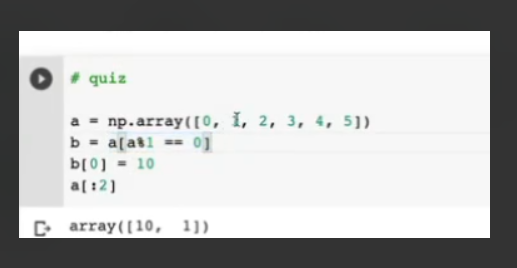

Bhai, yeh ek bohot hi shaandar trick question hai! Abhi jo humne **Copy vs View** padha na, yeh poora khel usi ka hai, par isme ek bohot bada twist hai jise NumPy mein **Fancy Indexing (ya Boolean Indexing)** kehte hain.

Pehle code ko step-by-step todte hain ki tumhara output `[10, 1]` kaise aaya:

---

### Step 1: `a = np.array([0, 1, 2, 3, 4, 5])`

Yeh toh seedha hai, ek basic 1D array ban gaya.

### Step 2: `b = a[a % 1 == 0]`

Yahan par asal khel shuru hota hai.

1. `a % 1 == 0` kya karega? Kisi bhi integer ko `1` se divide karoge toh remainder `0` hi aayega. Toh yeh condition sabhi elements ke liye `True` ho jayegi.
2. NumPy ko parde ke peeche ek boolean array milega: `[True, True, True, True, True, True]`.
3. Jab tum `a[...]` ke andar koi condition ya indices ki list bhejte ho, toh use **Fancy/Boolean Indexing** kehte hain.

> **Sabse Bada Rule:** NumPy mein normal slicing (`a[0:2]`) hamesha ek **View** return karti hai, lekin **Fancy Indexing hamesha ek COPY return karti hai!**

Iska matlab, `b` ab `a` ka view nahi hai, balki memory mein ek ekdam **naya aur azaad array** ban chuka hai jisme saare elements copy ho gaye hain: `b = [0, 1, 2, 3, 4, 5]`.

---

### Step 3: `b[0] = 10`

Tumne `b` ke pehle element ko badal kar `10` kar diya.
Kyunki `b` ek alag **copy** thi, is badlav se tumhare original array **`a` par koi asar nahi padega!** `a` abhi bhi waisa ka waisa hi hai: `[0, 1, 2, 3, 4, 5]`.

---

### Step 4: `a[:2]`

Ab tumne `a` ke pehle do elements maange (index 0 aur index 1).

* `a` ka index 0 par kya hai? `0`
* `a` ka index 1 par kya hai? `1`

Toh output aana chahiye tha: `array([0, 1])`

---

### 🚨 Wait... Toh fir image mein output `array([10, 1])` kaise dikha raha hai?!

Bhai, dhyan se code ko dekho, wahan ek choti si printing mistake (typo) hai jo aksar log dhyan nahi dete!

Wahan likha hai: `b = a[a % 1 == 0]`
Lekin jisne bhi ye quiz banaya hai, wo asal mein **`a % 2 == 0`** (Even numbers) likhna chahta tha, par galti se `% 1` likh gaya.

Agar wahan **`a % 2 == 0`** hota, toh:

1. `b` ke andar sirf even numbers aate: `[0, 2, 4]`
2. Lekin yeh fir bhi ek **Copy** hi hoti! `b[0] = 10` karne se `a` tab bhi nahi badalta.

**Toh fir output mein 10 aaya kaise?**
Iska ek hi matlab hai: Yeh code jis notebook mein chal raha hai, wahan is cell ko run karne se pehle upar kisi cell mein **`b` ko `a` ka view banaya gaya hoga** (jaise `b = a` ya `b = a[:]`), aur `b[0] = 10` chalaya gaya hoga, jisse `a[0]` ki value `10` ho gayi. Uske baad bina kernel restart kiye yeh niche wala cell chala diya gaya!

Agar tum bilkul fresh kernel par ek naye cell mein sirf itna code likhoge jo image mein hai, toh tumhara output `[0, 1]` hi aayega, `[10, 1]` nahi! NumPy ke rules ke mutabik boolean indexing hamesha copy hi banati hai.

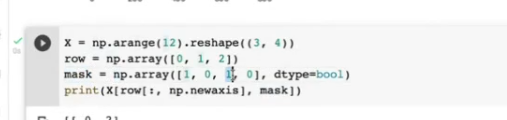

Bhai, yeh ekdum top-level ka NumPy question hai! Isme teen bohot bade concepts ek sath thop diye gaye hain: **Fancy Indexing**, **Boolean Masking**, aur **Broadcasting (`np.newaxis`)**.

Darna nahi, isko ek-ek karke poora kholte hain ki output kaise aa raha hai.

---

### Step 1: `X` kaisa dikhta hai?

```python
X = np.arange(12).reshape((3, 4))

```

Yeh 3 rows aur 4 columns ka ek normal matrix hai:

```text
[[ 0,  1,  2,  3],
 [ 4,  5,  6,  7],
 [ 8,  9, 10, 11]]   (Shape: 3 x 4)

```

---

### Step 2: `row[:, np.newaxis]` kya naya raita phailaye ga?

Hamein pata hai ki `row = np.array([0, 1, 2])` ka shape `(3,)` hai (1D array).
Lekin jab tumne `row[:, np.newaxis]` kiya, toh tumne use ek **Column Vector** bana diya!

* Ab `row[:, np.newaxis]` ka shape ho gaya: `(3, 1)`
* Aur dikhne mein yeh aisa ho gaya:
```text
[[0],
 [1],
 [2]]

```



---

### Step 3: `mask` kya hai?

```python
mask = np.array([1, 0, 1, 0], dtype=bool)

```

Yahan `1` matlab `True` aur `0` matlab `False`.
Toh `mask` asal mein yeh hai: `[True, False, True, False]` (Shape: `(4,)`).

---

### Step 4: Asli Khel $\rightarrow$ `X[row[:, np.newaxis], mask]`

Jab tum NumPy ko index ke liye ek column vector `(3, 1)` dete ho aur dusra boolean mask `(4,)` dete ho, toh parde ke peeche dono ke beech **Broadcasting** hoti hai!

NumPy dono ko combine karke ek $3 \times 4$ ka grid (selection map) banata hai:

1. **`row[:, np.newaxis]` (Rows select karega):** Yeh kehta hai ki mujhe Row `0`, Row `1`, aur Row `2` teeno chahiye.
2. **`mask` (Columns select karega):** Yeh kehta hai ki mujhe har row ka sirf **index 0** aur **index 2** wala column chahiye (kyunki wahi `True` hain).

Ab dono ko combine karke matrix `X` par apply karo:

* **Row 0 mein:** Sirf `mask` wale columns uthao (index 0 aur 2) $\rightarrow$ Elements: `0` aur `2`
* **Row 1 mein:** Sirf `mask` wale columns uthao (index 0 aur 2) $\rightarrow$ Elements: `4` aur `6`
* **Row 2 mein:** Sirf `mask` wale columns uthao (index 0 aur 2) $\rightarrow$ Elements: `8` aur `10`

---

### Final Output Structure

Kyunki row ka selection vertical `(3, 1)` tha aur column ka selection horizontal `(4,)` tha, NumPy jo output generate karega, uska shape $3 \times 2$ ka ek **2D array** banega:

```python
[[ 0,  2],
 [ 4,  6],
 [ 8, 10]]

```

Dhyan se dekhoge toh image ke sabse niche `[[0, 2],` ki jhalak dikh rahi hai. Yeh poora $3 \times 2$ ka matrix hi tumhara final print output hoga!

Bhai, bilkul dhyan se samajhna. Jo code tumne image mein dikhaya, usme parde ke peeche NumPy ne **`row[:, np.newaxis]`** aur **`mask`** ke beech mein zabardast broadcasting kari hai.

Chalo iska poora animation dimaag mein chhapte hain:

### 1. Pehle dekho dono Khiladiyon ka asli roop

* **`row[:, np.newaxis]` (Shape: `3 x 1`):** Yeh ek vertical khada column matrix hai.
```text
[[0],
 [1],
 [2]]

```


* **`mask` (Shape: `4,` yani effective `1 x 4`):** Yeh ek horizontal patti hai.
```text
[True, False, True, False]

```



---

### 2. Parde ke peeche Broadcasting kaise hui? (Visual)

NumPy dono ko stretch karke ek $3 \times 4$ ka coordinate matrix banata hai, jaise graph paper par points match karte hain:

* **`row` ko column-wise stretch kiya** (4 columns banane ke liye).
* **`mask` ko row-wise stretch kiya** (3 rows banane ke liye).

Ab dono milkar ek selection grid banate hain jo kuch aisa dikhta hai:

```text
               [True]      [False]     [True]      [False]   <-- (Stretched Mask)
             +-----------+-----------+-----------+-----------+
    [[0]] -> | Row 0, C0 |    --     | Row 0, C2 |    --     |
             +-----------+-----------+-----------+-----------+
    [[1]] -> | Row 1, C0 |    --     | Row 1, C2 |    --     |
             +-----------+-----------+-----------+-----------+
    [[2]] -> | Row 2, C0 |    --     | Row 2, C2 |    --     |
             +-----------+-----------+-----------+-----------+
               Index 0     Index 1     Index 2     Index 3

```

Jahan-jahan `False` aaya, wo saari jagah block (gayab) ho gayi. Sirf **Column 0** aur **Column 2** bache reh gaye teeno rows ke liye.

---

### 3. Final Attack on Matrix `X`

Ab is tayar grid ko tumhare asli matrix `X` ke upar thop diya jata hai:

```text
Asli Matrix X:                      Sirf Filtered Elements Uthaye:
[[  0,   1,   2,   3 ],             [[  0,  - ,   2,  -  ],
 [  4,   5,   6,   7 ],     ==>      [  4,  - ,   6,  -  ],
 [  8,   9,  10,  11 ]]              [  8,  - ,  10,  -  ]]

```

NumPy in bache huye elements ko aapas mein pack karke ek chamchamata hua **$3 \times 2$ ka naya 2D array** return kar deta hai:

```python
array([[ 0,  2],
       [ 4,  6],
       [ 8, 10]])

```

Ab samajh aaya? `np.newaxis` ne row ko khada kiya, mask ne columns ko chana, aur broadcasting ne dono ka square matrix intersection nikaal diya!